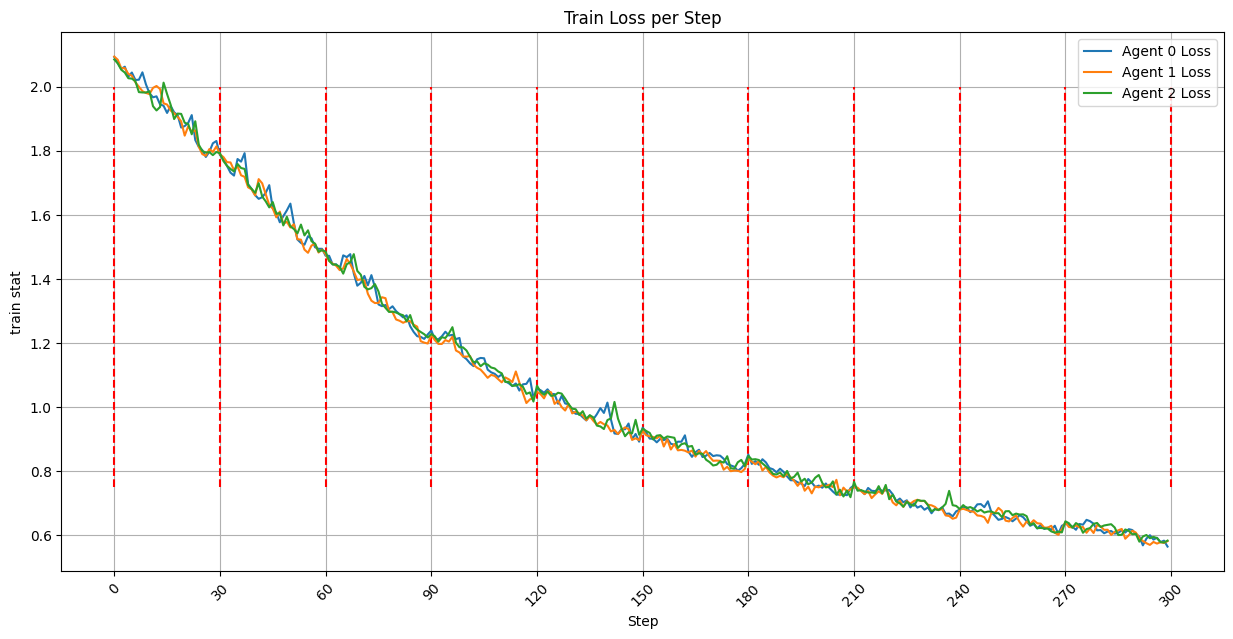

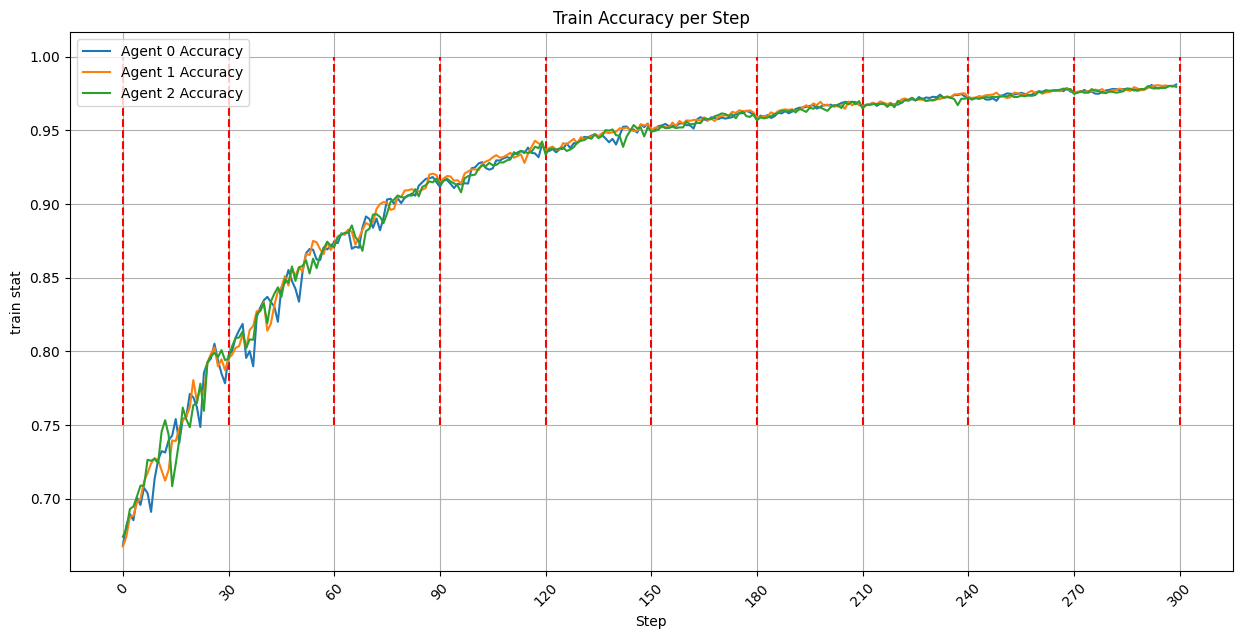

In [51]:
from matplotlib import pyplot as plt
import pandas as pd

fodler = 'basic_compression'
path_to_stats = f'exp_data/compression_stats_report/{fodler}'
agent_count = 3
round_count = 10
step_count = None

plot_data=[[],[]]

round_x = 0
for i in range(agent_count):
    agents_loss = []
    agents_accuracy = []
    round_x_loc = [0]
    for j in range(round_count):
        file_path = f"{path_to_stats}/agent_{i}_round_{j}/version_0/metrics.csv"
        data = pd.read_csv(file_path).values
        if step_count is None:
            step_count = len(data)
        round_x_loc += [round_x_loc[-1] + step_count]
        agents_loss += data[:, 3].tolist()
        agents_accuracy += data[:, 2].tolist()
    plot_data[0].append(agents_accuracy)
    plot_data[1].append(agents_loss)

plt.figure(figsize=(15, 7))
plt.xlabel('Step')
plt.ylabel('train stat')
plt.title('Train Loss per Step')
plt.xticks(round_x_loc, rotation=45)
plt.grid(True)
plt.vlines(round_x_loc, 0.75,2, linestyles='dashed', colors='red')
for ag_id in range(agent_count):
    # plt.plot(plot_data[0][ag_id], label=f'Agent {ag_id} Accuracy')
    plt.plot(plot_data[1][ag_id], label=f'Agent {ag_id} Loss')
plt.legend()
plt.show()

plt.figure(figsize=(15, 7))
plt.xlabel('Step')
plt.ylabel('train stat')
plt.title('Train Accuracy per Step')
plt.xticks(round_x_loc, rotation=45)
plt.grid(True)
plt.vlines(round_x_loc, 0.75,1, linestyles='dashed', colors='red')
for ag_id in range(agent_count):
    plt.plot(plot_data[0][ag_id], label=f'Agent {ag_id} Accuracy')
    # plt.plot(plot_data[1][ag_id], label=f'Agent {ag_id} Loss')
plt.legend()
plt.show()


In [52]:
import torch

compression_stats = torch.load(f"{path_to_stats}/compression_stats.pth", map_location='cpu')

In [53]:
raw_data_size = [[],[],[]]
entropy_data_size = [[],[],[]]
wz_data_size = [[],[],[]]# <-------
total_error = [[],[],[]]
for round_idx in range(round_count): # <-------
    for ag_idx in range(agent_count):
        k='KB size info per agent'
        byte_size_stat = compression_stats[round_idx][k]
        raw_data_size[ag_idx].append(byte_size_stat['raw'][ag_idx])
        entropy_data_size[ag_idx].append(byte_size_stat['entropy'][ag_idx])
        wz_data_size[ag_idx].append(byte_size_stat['wz'][ag_idx])

        k='% total error per agent'
        total_error[ag_idx].append(compression_stats[round_idx][k][ag_idx])


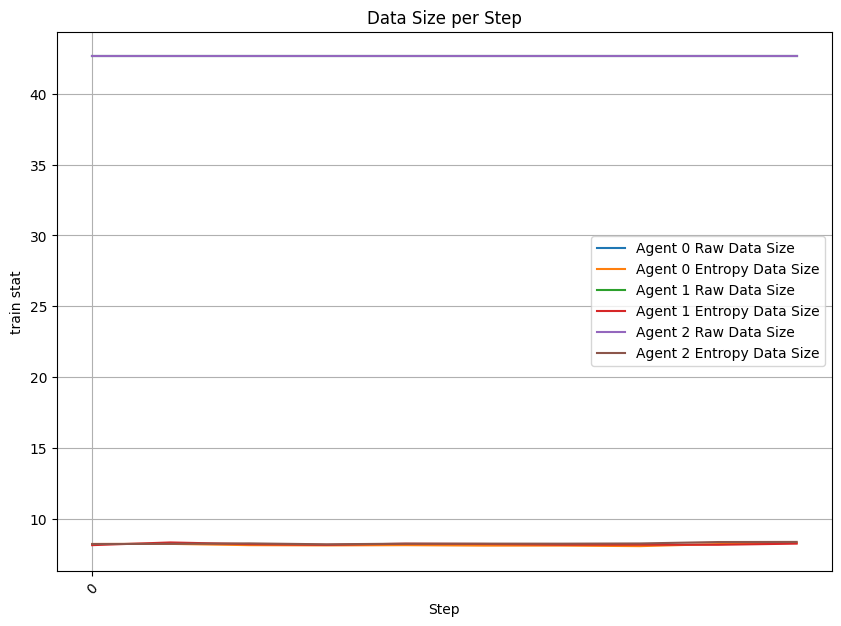

In [54]:
plt.figure(figsize=(10, 7))
plt.xlabel('Step')
plt.ylabel('train stat')
plt.title('Data Size per Step')
plt.xticks(round_x_loc, rotation=45)
plt.grid(True)
for ag_id in range(agent_count):
    plt.plot(raw_data_size[ag_id], label=f'Agent {ag_id} Raw Data Size')
    plt.plot(entropy_data_size[ag_id], label=f'Agent {ag_id} Entropy Data Size')
    # plt.plot(wz_data_size[ag_id], label=f'Agent {ag_id} WZ Data Size')
plt.legend()
plt.show()


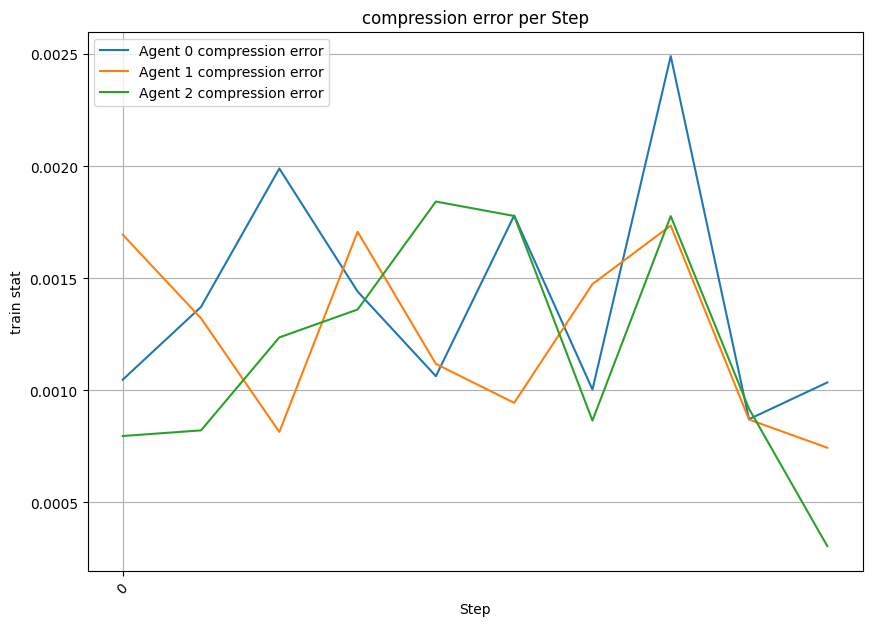

In [55]:
plt.figure(figsize=(10, 7))
plt.xlabel('Step')
plt.ylabel('train stat')
plt.title('compression error per Step')
plt.xticks(round_x_loc, rotation=45)
plt.grid(True)
for ag_id in range(agent_count):
    plt.plot(total_error[ag_id], label=f'Agent {ag_id} compression error')
    # plt.plot(wz_data_size[ag_id], label=f'Agent {ag_id} WZ Data Size')
plt.legend()
plt.show()


In [56]:
complete_data= {'base':[plot_data, raw_data_size, entropy_data_size, wz_data_size, total_error,],
        'wz':[]}

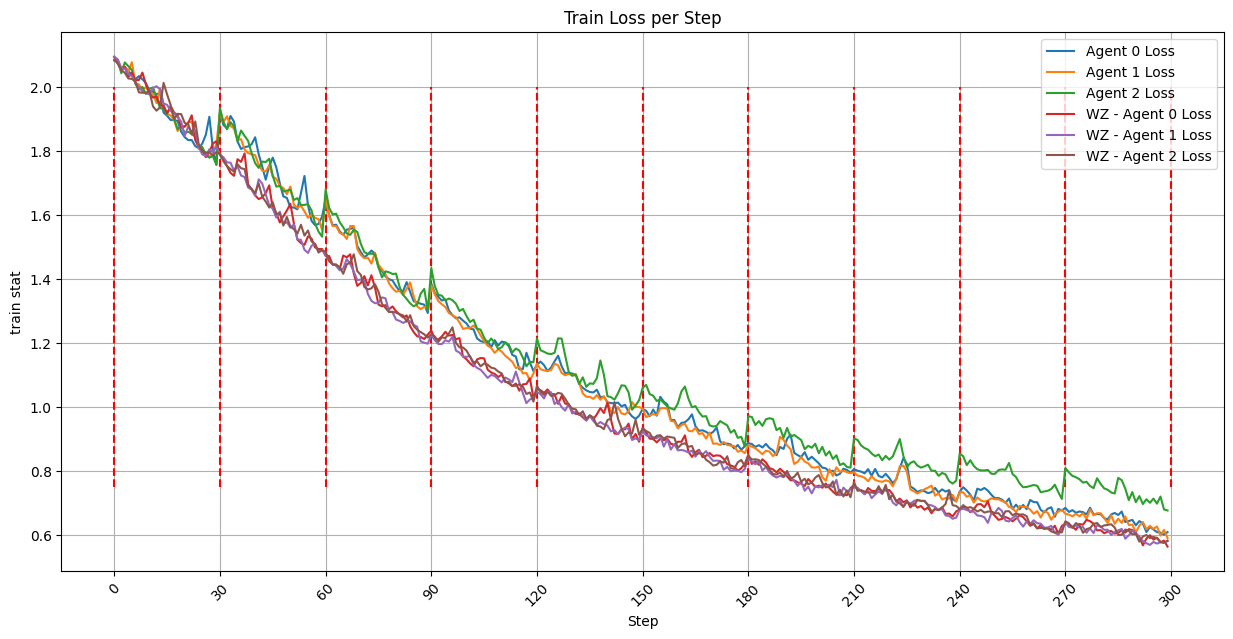

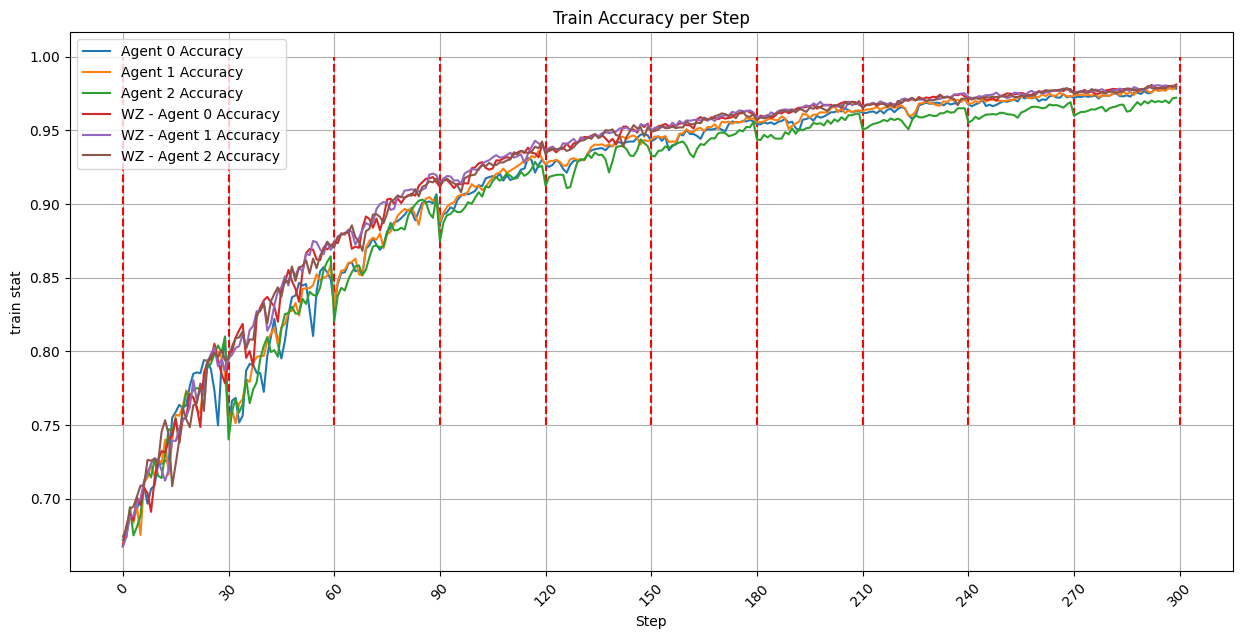

In [57]:
from matplotlib import pyplot as plt
import pandas as pd

fodler = 'wz_quantizer'
path_to_stats = f'exp_data/compression_stats_report/{fodler}'
agent_count = 3
round_count = 10
step_count = None

plot_data = [[], []]
other_plot_data = complete_data['base'][0]

round_x = 0
for i in range(agent_count):
    agents_loss = []
    agents_accuracy = []
    round_x_loc = [0]
    for j in range(round_count):
        file_path = f"{path_to_stats}/agent_{i}_round_{j}/version_0/metrics.csv"
        data = pd.read_csv(file_path).values
        if step_count is None:
            step_count = len(data)
        round_x_loc += [round_x_loc[-1] + step_count]
        agents_loss += data[:, 3].tolist()
        agents_accuracy += data[:, 2].tolist()
    plot_data[0].append(agents_accuracy)
    plot_data[1].append(agents_loss)

plt.figure(figsize=(15, 7))
plt.xlabel('Step')
plt.ylabel('train stat')
plt.title('Train Loss per Step')
plt.xticks(round_x_loc, rotation=45)
plt.grid(True)
plt.vlines(round_x_loc, 0.75, 2, linestyles='dashed', colors='red')
for ag_id in range(agent_count):
    # plt.plot(plot_data[0][ag_id], label=f'Agent {ag_id} Accuracy')
    plt.plot(plot_data[1][ag_id], label=f'Agent {ag_id} Loss')
for ag_id in range(agent_count):
    # plt.plot(plot_data[0][ag_id], label=f'Agent {ag_id} Accuracy')
    plt.plot(other_plot_data[1][ag_id], label=f'WZ - Agent {ag_id} Loss')
plt.legend()
# plt.show()

plt.figure(figsize=(15, 7))
plt.xlabel('Step')
plt.ylabel('train stat')
plt.title('Train Accuracy per Step')
plt.xticks(round_x_loc, rotation=45)
plt.grid(True)
plt.vlines(round_x_loc, 0.75, 1, linestyles='dashed', colors='red')
for ag_id in range(agent_count):
    plt.plot(plot_data[0][ag_id], label=f'Agent {ag_id} Accuracy')
    # plt.plot(plot_data[1][ag_id], label=f'Agent {ag_id} Loss')
for ag_id in range(agent_count):
    plt.plot(other_plot_data[0][ag_id], label=f'WZ - Agent {ag_id} Accuracy')
plt.legend()
plt.show()

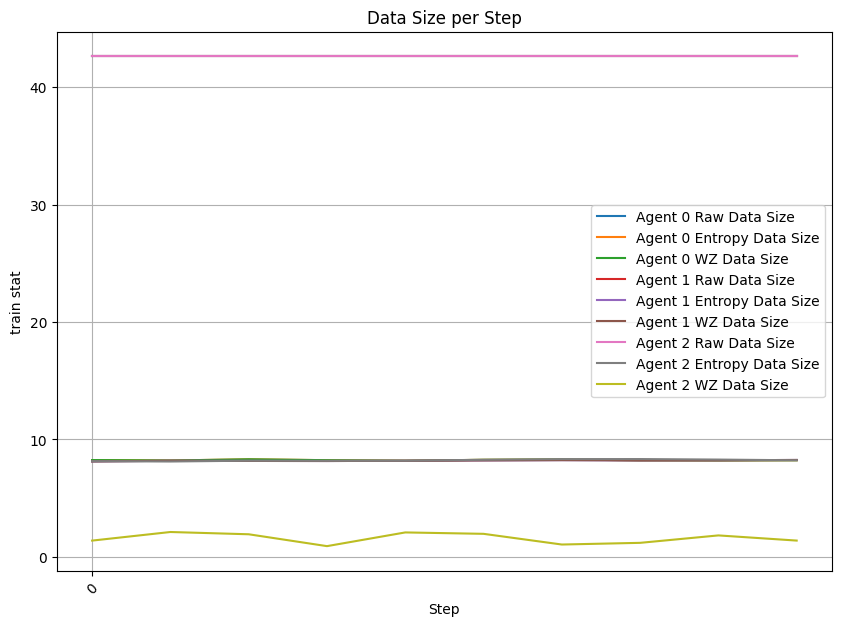

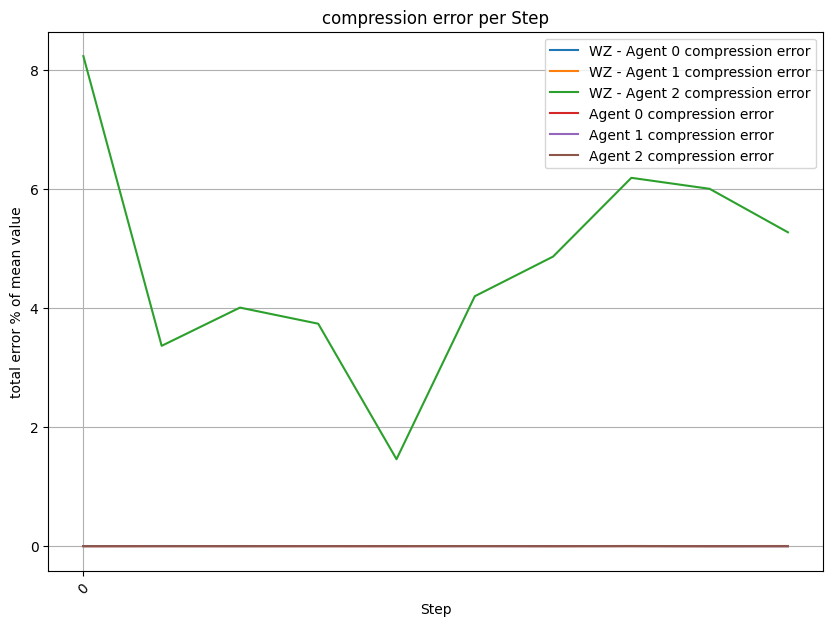

In [58]:
import torch

compression_stats = torch.load(f"{path_to_stats}/compression_stats.pth", map_location='cpu')
raw_data_size = [[], [], []]
entropy_data_size = [[], [], []]
wz_data_size = [[], [], []]  # <-------
total_error = [[], [], []]
for round_idx in range(round_count):  # <-------
    for ag_idx in range(agent_count):
        k = 'KB size info per agent'
        byte_size_stat = compression_stats[round_idx][k]
        raw_data_size[ag_idx].append(byte_size_stat['raw'][ag_idx])
        entropy_data_size[ag_idx].append(byte_size_stat['entropy'][ag_idx])
        wz_data_size[ag_idx].append(byte_size_stat['wz'][ag_idx])

        k = '% total error per agent'
        total_error[ag_idx].append(compression_stats[round_idx][k][ag_idx])

plt.figure(figsize=(10, 7))
plt.xlabel('Step')
plt.ylabel('train stat')
plt.title('Data Size per Step')
plt.xticks(round_x_loc, rotation=45)
plt.grid(True)
# for ag_id in range(agent_count):
    # plt.plot(raw_data_size[ag_id], label=f'Agent {ag_id} Raw Data Size')
    # plt.plot(entropy_data_size[ag_id], label=f'Agent {ag_id} Entropy Data Size')
    # plt.plot(wz_data_size[ag_id], label=f'Agent {ag_id} WZ Data Size')
for ag_id in range(agent_count):
    plt.plot(raw_data_size[ag_id], label=f'Agent {ag_id} Raw Data Size')
    plt.plot(entropy_data_size[ag_id], label=f'Agent {ag_id} Entropy Data Size')
    plt.plot(wz_data_size[ag_id], label=f'Agent {ag_id} WZ Data Size')
plt.legend()
plt.show()

plt.figure(figsize=(10, 7))
plt.xlabel('Step')
plt.ylabel('total error % of mean value')
plt.title('compression error per Step')
plt.xticks(round_x_loc, rotation=45)
plt.grid(True)
for ag_id in range(agent_count):
    plt.plot(total_error[ag_id], label=f'WZ - Agent {ag_id} compression error')
for ag_id in range(agent_count):
    plt.plot(complete_data['base'][-1][ag_id], label=f'Agent {ag_id} compression error')
plt.legend()
plt.show()

